<p><b><u>TRAIN CLASSIFIER FOR IMAGES IN THE FOLDER:</u></b></p>
<ul>
    <li>- E:/HeaRTLabInstrumentData/{Instrument Name}/blue/Session_1/top_camera/right_side_up/static_closed</li>
</ul>

<p><b><u>ONLY WORKING ON TRAINING THESE INSTRUMENTS FOR NOW [MEANS TOTAL INSTRUMENTS IN THE PATH ABOVE]</u></b></p>
<ul>
    <li><b>SIMILAR INSTRUMENTS</b></li>
        <li style="list-style-type: none;"><pre>- [1820] Needle Holder, Mayo-Hegar Straight Carb-bite Serrated Jaws 8in</pre></li>
        <li style="list-style-type: none;"><pre>- [1820] Needle Holder, Ryder Straight Carb-bite Serrated Jaws 8in</pre></li>
    <li><b>TOTALLY DIFFERENT INSTRUMENT</b></li>
        <li style="list-style-type: none;"><pre>- [1820] Sponge Holding Forceps, Foerster Straight Serrated 9.5in</pre></li>
</ul>

In [ ]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path

parent_dir = str(Path().resolve().parent)

if parent_dir not in sys.path:
    sys.path.append(parent_dir)
    
from data_loaders.masterTestDataLoader import loadAndSaveData

In [ ]:
"""
FILTER OUT STEPS 6-20 (ONLY 1/4 OF THE STEP DATA IS REQUIRED, AS TECHNICALLY EVERYTHING ELSE IS JUST A PROJECTION OF THIS 1/4)
    -> S1 - S20 :: KEEP S1-S5 only for each

DONE BY masterDataLoader.py
"""

# load and save data
loadAndSaveData(root_dir="E:\\HeaRTLabInstrumentData", csvSave="..\\data\\metadata.csv")

# Load the data into a pandas dataframe [SUCCESSFULLY LOADS ALL IMAGES AND METADATA]
df = pd.DataFrame(pd.read_csv("..\\data\\metadata.csv"))

# MAKE TABLE EVEN MORE CONCISE BY EDITING THE masterDataLoader.py file
# SX - step [remove]
# L - lights that are on
# B - brightness

"""
FILTER OUT SIDE CAMERA DATA

CHANGE THESE WHEN NEEDED
"""
instruments = [
    "Needle Holder, Mayo-Hegar Straight Carb-bite Serrated Jaws 8in",
    "Needle Holder, Ryder Straight Carb-bite Serrated Jaws 8in", 
    "Sponge Holding Forceps, Foerster Straight Serrated 9.5in"
]
camera = ["top_camera"]
orientation = ["right_side_up"]
state = ["static_closed", "static_open"]
background = ["blue"]

df_filtered = df[
    (df["instrument"].isin(instruments)) &
    (df["camera"].isin(camera)) &
    (df["orientation"].isin(orientation)) &
    (df["state"].isin(state)) &
    (df["background"].isin(background))
]

# Filter and assign labels
label_map = {name: i for i, name in enumerate(df_filtered["instrument"].unique())}
labels = df_filtered["instrument"].map(label_map)
idx = df_filtered.columns.get_loc("instrument")
df_filtered.insert(idx + 1, "label", labels)

df_filtered

,image_path,instrument,label,background,orientation,state,lights,brightness,camera
18200,E:\HeaRTLabInstrumentData\Sponge Holding Force...,"Sponge Holding Forceps, Foerster Straight Serr...",0,blue,right_side_up,static_closed,L1_2_3_4,100,top_camera
18201,E:\HeaRTLabInstrumentData\Sponge Holding Force...,"Sponge Holding Forceps, Foerster Straight Serr...",0,blue,right_side_up,static_closed,L1_2_3_4,120,top_camera
18202,E:\HeaRTLabInstrumentData\Sponge Holding Force...,"Sponge Holding Forceps, Foerster Straight Serr...",0,blue,right_side_up,static_closed,L1_2_3_4,140,top_camera
18203,E:\HeaRTLabInstrumentData\Sponge Holding Force...,"Sponge Holding Forceps, Foerster Straight Serr...",0,blue,right_side_up,static_closed,L1_2_3_4,160,top_camera
18204,E:\HeaRTLabInstrumentData\Sponge Holding Force...,"Sponge Holding Forceps, Foerster Straight Serr...",0,blue,right_side_up,static_closed,L1_2_3_4,180,top_camera
...,...,...,...,...,...,...,...,...,...
87495,"E:\HeaRTLabInstrumentData\Needle Holder, Mayo-...","Needle Holder, Mayo-Hegar Straight Carb-bite S...",2,blue,right_side_up,static_closed,L2_3,140,top_camera
87496,"E:\HeaRTLabInstrumentData\Needle Holder, Mayo-...","Needle Holder, Mayo-Hegar Straight Carb-bite S...",2,blue,right_side_up,static_closed,L3_4,140,top_camera
87497,"E:\HeaRTLabInstrumentData\Needle Holder, Mayo-...","Needle Holder, Mayo-Hegar Straight Carb-bite S...",2,blue,right_side_up,static_closed,L1_4,140,top_camera
87498,"E:\HeaRTLabInstrumentData\Needle Holder, Mayo-...","Needle Holder, Mayo-Hegar Straight Carb-bite S...",2,blue,right_side_up,static_closed,L1_2_3,140,top_camera


## TRAIN/VALIDATION SPLIT

In [3]:
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import DataLoader
from data_loaders.InstrumentDataset import InstrumentDataset

In [4]:
# Split the data into training and testing datasets

# Create grouping key (IMPORTANT)
df_filtered["group"] = df_filtered["instrument"] + "_" + df_filtered["lights"]

# Group-based split
gss = GroupShuffleSplit(test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(df_filtered, groups=df_filtered["group"]))

trainDF = df_filtered.iloc[train_idx]
testDF = df_filtered.iloc[test_idx]

In [5]:
# get the instrument data by using the InstrumentDataset class
trainDataset = InstrumentDataset(trainDF)
testDataset = InstrumentDataset(testDF)

# load the data
trainLoader = DataLoader(trainDataset, batch_size=32, shuffle=True, num_workers=4)
testLoader = DataLoader(testDataset, batch_size=32, shuffle=False, num_workers=4)

### ResNet18

In [6]:
import torch.nn
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

# create the resnet model
model = resnet18(weights=ResNet18_Weights.DEFAULT)

# replace final layer
model.fc = nn.Linear(model.fc.in_features, 3)

# initialize model in device (preferably GPU)
model = model.to(device)

# confirmation
print("MODEL INITIALIZED!")

Using: cuda
MODEL INITIALIZED!


In [8]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [10]:
loss_file = "models/RC_best_loss.txt"

# Load previous best loss if it exists
if os.path.exists(loss_file):
    with open(loss_file, "r") as f:
        bestValLoss = float(f.read())
    print(f"Loaded previous best loss: {bestValLoss}")
else:
    bestValLoss = float('inf')
    print("No previous loss found, starting fresh.")

# TRAINING LOOP
for epoch in range(50):
    model.train()
    total_loss = 0

    for imgs, labels in trainLoader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    if total_loss < bestValLoss:
        bestValLoss = total_loss
        
        # save model
        torch.save(model.state_dict(), 'models\\regularClassifierModel_weights.pth')

        # save loss
        with open(loss_file, "w") as f:
            f.write(str(bestValLoss))
        
        print("\t=> Best Model + Loss Saved!")

No previous loss found, starting fresh.
Epoch 1, Loss: 0.3563
	=> Best Model + Loss Saved!
Epoch 2, Loss: 0.1374
	=> Best Model + Loss Saved!
Epoch 3, Loss: 3.5362
Epoch 4, Loss: 0.0674
	=> Best Model + Loss Saved!
Epoch 5, Loss: 0.0550
	=> Best Model + Loss Saved!
Epoch 6, Loss: 0.0291
	=> Best Model + Loss Saved!
Epoch 7, Loss: 0.0211
	=> Best Model + Loss Saved!
Epoch 8, Loss: 0.0253
Epoch 9, Loss: 0.0170
	=> Best Model + Loss Saved!
Epoch 10, Loss: 0.0130
	=> Best Model + Loss Saved!
Epoch 11, Loss: 0.0096
	=> Best Model + Loss Saved!
Epoch 12, Loss: 0.0091
	=> Best Model + Loss Saved!
Epoch 13, Loss: 0.0084
	=> Best Model + Loss Saved!
Epoch 14, Loss: 0.0078
	=> Best Model + Loss Saved!
Epoch 15, Loss: 0.0091
Epoch 16, Loss: 0.0072
	=> Best Model + Loss Saved!
Epoch 17, Loss: 0.0044
	=> Best Model + Loss Saved!
Epoch 18, Loss: 0.0042
	=> Best Model + Loss Saved!
Epoch 19, Loss: 0.0048
Epoch 20, Loss: 0.0030
	=> Best Model + Loss Saved!
Epoch 21, Loss: 0.0025
	=> Best Model + Loss 

In [ ]:
# load best weights
model.load_state_dict(torch.load('models\\regularClassifierModel_weights.pth', weights_only=True))
model.eval()

# TESTING LOOP
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in testLoader:
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Validation Accuracy: {100 * correct / total:.2f}%")

Validation Accuracy: 99.96%


: 

# TESTED WITH TESTING PORTION OF DATA - NOW, CREATE SESSION_2 WITH NEW DATA FOR ALL 3 INSTRUMENTS AND TEST WITH THAT

In [12]:
from torchvision import transforms
from PIL import Image
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [13]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

camera = "top_camera"
background = "blue"
orient = "right_side_up"
config = "static_closed"
lightingPattern = "S2_L2_B100" # DARKER CONDITION

testSHF = f"Sponge Holding Forceps, Foerster Straight Serrated 9.5in_{background}_{orient}_{config}_{lightingPattern}_{camera}.jpg"
testNHMH = f"Needle Holder, Mayo-Hegar Straight Carb-bite Serrated Jaws 8in_{background}_{orient}_{config}_{lightingPattern}_{camera}.jpg"
testRSCB = f"Needle Holder, Ryder Straight Carb-bite Serrated Jaws 8in_{background}_{orient}_{config}_{lightingPattern}_{camera}.jpg"

img_pathSHF = f"E:\\HeaRTLabInstrumentData\\Sponge Holding Forceps, Foerster Straight Serrated 9.5in\\{background}\\Session_1\\{camera}\\{orient}\\{config}\\{testSHF}"
img_pathNHMH = f"E:\\HeaRTLabInstrumentData\\Needle Holder, Mayo-Hegar Straight Carb-bite Serrated Jaws 8in\\{background}\\Session_1\\{camera}\\{orient}\\{config}\\{testNHMH}"

# VERY SIMILAR TO NHMH
img_pathRSCB = f"E:\\HeaRTLabInstrumentData\\Needle Holder, Ryder Straight Carb-bite Serrated Jaws 8in\\{background}\\Session_1\\{camera}\\{orient}\\{config}\\{testRSCB}"

In [14]:
print(f"Configuration Trained\n\t- CAMERA: top_camera\n\t- BACKGROUND: blue\n\t- ORIENTATION: right_side_up\n\t- CONGIFURATION: static_closed, static_open\n\t- LIGHTING PATTERN: all\n")
print(f"Configuration Checked\n\t- CAMERA: {camera}\n\t- BACKGROUND: {background}\n\t- ORIENTATION: {orient}\n\t- CONGIFURATION: {config}\n\t- LIGHTING PATTERN: {lightingPattern}\n")

Configuration Trained
	- CAMERA: top_camera
	- BACKGROUND: blue
	- ORIENTATION: right_side_up
	- CONGIFURATION: static_closed, static_open
	- LIGHTING PATTERN: all

Configuration Checked
	- CAMERA: top_camera
	- BACKGROUND: blue
	- ORIENTATION: right_side_up
	- CONGIFURATION: static_closed
	- LIGHTING PATTERN: S2_L2_B100



In [15]:
for path in [img_pathSHF, img_pathNHMH, img_pathRSCB]:
    image = Image.open(path).convert("RGB")
    image = transform(image)

    # add batch dimension ONCE
    image = image.unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        outputs = model(image)
        probs = torch.softmax(outputs, dim=1)
        pred = torch.argmax(probs, dim=1)

    inv_label_map = {v: k for k, v in label_map.items()}

    print()
    print(path)
    print("\t- Is test image in train set?", path in trainDF["image_path"].values)
    print("\t- Is test image in test set?", path in testDF["image_path"].values)
    print(f"\t- Prediction:", inv_label_map[pred.item()])
    print(f"\t- Confidence:", probs[0][pred.item()].item())
    print()


E:\HeaRTLabInstrumentData\Sponge Holding Forceps, Foerster Straight Serrated 9.5in\blue\Session_1\top_camera\right_side_up\static_closed\Sponge Holding Forceps, Foerster Straight Serrated 9.5in_blue_right_side_up_static_closed_S2_L2_B100_top_camera.jpg
	- Is test image in train set? False
	- Is test image in test set? True
	- Prediction: Sponge Holding Forceps, Foerster Straight Serrated 9.5in
	- Confidence: 0.9959383010864258


E:\HeaRTLabInstrumentData\Needle Holder, Mayo-Hegar Straight Carb-bite Serrated Jaws 8in\blue\Session_1\top_camera\right_side_up\static_closed\Needle Holder, Mayo-Hegar Straight Carb-bite Serrated Jaws 8in_blue_right_side_up_static_closed_S2_L2_B100_top_camera.jpg
	- Is test image in train set? True
	- Is test image in test set? False
	- Prediction: Needle Holder, Mayo-Hegar Straight Carb-bite Serrated Jaws 8in
	- Confidence: 1.0


E:\HeaRTLabInstrumentData\Needle Holder, Ryder Straight Carb-bite Serrated Jaws 8in\blue\Session_1\top_camera\right_side_up\static

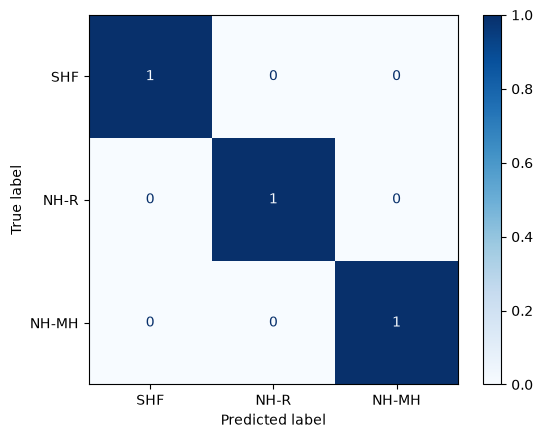

In [16]:
all_preds = []
all_labels = []

test_paths = [
    (img_pathSHF, "Sponge Holding Forceps, Foerster Straight Serrated 9.5in"),
    (img_pathNHMH, "Needle Holder, Mayo-Hegar Straight Carb-bite Serrated Jaws 8in"),
    (img_pathRSCB, "Needle Holder, Ryder Straight Carb-bite Serrated Jaws 8in")
]

for path, instrument_name in test_paths:
    true_label = label_map[instrument_name]

    image = Image.open(path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        pred = torch.argmax(outputs, dim=1).item()

    all_preds.append(pred)
    all_labels.append(true_label)

cm = confusion_matrix(all_labels, all_preds)

abbrev_labels = {
    "Needle Holder, Mayo-Hegar Straight Carb-bite Serrated Jaws 8in": "NH-MH",
    "Needle Holder, Ryder Straight Carb-bite Serrated Jaws 8in": "NH-R",
    "Sponge Holding Forceps, Foerster Straight Serrated 9.5in": "SHF"
}

display_labels = [
    abbrev_labels[name]
    for name in label_map.keys()
]

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_labels
)

disp.plot(cmap="Blues")
plt.show()